# Q2 - Distance Matrix Computation using Two Methods

In this lab I am computing a pairwise distance matrix using two distance methods, Euclidean distance and Manhattan distance. I am using the placement survey data (lab2 data.xlsx) and the sklearn pairwise_distances function as given in the reference link.

Reference used: Unit 2 slides (distance metrics topic) and scikit-learn pairwise_distances documentation.

In [1]:
import re
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import pairwise_distances

pd.set_option('display.max_columns', None)

## Loading the dataset

First I load the excel file and check the shape.

In [2]:
df = pd.read_excel("lab2 data.xlsx")
df.shape

(163, 14)

## Cleaning the data

The dataset has some columns that are not clean. For example the package expectation column has values like "20 LPA", "5LPA", "10 lac", plain numbers, and even some text answers. The percentage columns (CIA, GPA, attendance) also have a mix, some students entered percentage as decimal (0.67) and some entered it as whole number (67).

I wrote two small functions to fix these columns so they become plain numbers, then picked the columns I need and dropped rows with missing values.

In [3]:
def clean_percent(val):
    if pd.isna(val):
        return None
    s = str(val).strip()
    if s in ("-", "", "nan"):
        return None
    try:
        num = float(s)
    except ValueError:
        return None
    if num <= 1:
        return num * 100
    return num


def clean_package(val):
    if pd.isna(val):
        return None
    s = str(val).strip().lower().replace(",", "")
    if not re.search(r"\d", s):
        return None
    nums = re.findall(r"[\d.]+", s)
    if not nums:
        return None
    num = float(nums[0])
    if "lac" in s or "lakh" in s or "lpa" in s:
        return num
    if num > 1000:
        return num / 100000
    return num


clean = pd.DataFrame({
    "Reg No": df["Reg No"],
    "Extracurricular_rating": df["Rate your contribution towards extra curricular activities"],
    "Technical_rating": df["Rate your technical competencies"],
    "Package_expectation_LPA": df["What are your package expectations (LPA)"].apply(clean_package),
    "CIA_pct": df["your CIA % of last semester"].apply(clean_percent),
    "GPA_pct": df["your GPA of last semester"].apply(clean_percent),
    "Attendance_pct": df["Your maximum attendance % till last semester"].apply(clean_percent),
})
clean = clean.dropna()
clean.shape

(142, 7)

## Selecting a sample and scaling

For the distance matrix I am taking the first 8 students from the cleaned data. I am naming them S1 to S8 since some Reg No repeat in the sheet (looks like the same student filled the form more than once).

The 6 features I am using are on very different scales, rating is 1 to 5, percentage is 0 to 100, package is in LPA. If I calculate distance directly on these values, package and percentage columns will dominate just because their numbers are bigger. So I scaled all features using StandardScaler before computing distance.

In [4]:
sample = clean.head(8).reset_index(drop=True)
labels = [f"S{i+1}" for i in range(len(sample))]
reg_map = dict(zip(labels, sample["Reg No"].astype(str)))
print(reg_map)

feature_cols = [
    "Extracurricular_rating", "Technical_rating", "Package_expectation_LPA",
    "CIA_pct", "GPA_pct", "Attendance_pct",
]
sample[feature_cols]

{'S1': '2341338', 'S2': '2341310', 'S3': '2341311', 'S4': '2341324', 'S5': '2341324', 'S6': '2341324', 'S7': '2341324', 'S8': '13_007'}


,Extracurricular_rating,Technical_rating,Package_expectation_LPA,CIA_pct,GPA_pct,Attendance_pct
0,3.0,4,20.0,60.0,62.0,77.0
1,3.0,2,11.0,67.0,60.0,97.0
2,3.0,4,5.0,80.0,80.0,99.0
3,3.0,3,20.0,65.0,76.0,96.0
4,3.0,2,40.0,79.0,69.0,98.0
5,5.0,5,20.0,68.0,80.0,99.0
6,4.0,4,25.0,75.0,87.0,97.0
7,5.0,5,20.0,65.0,70.0,98.0


In [5]:
X = StandardScaler().fit_transform(sample[feature_cols].values)
X

array([[-0.72932496,  0.33752637, -0.01307776, -1.45426143, -1.25153627,
        -2.61995905],
       [-0.72932496, -1.46261427, -0.95467668, -0.42339257, -1.47908832,
         0.27103025],
       [-0.72932496,  0.33752637, -1.58240929,  1.49107818,  0.79643217,
         0.56012918],
       [-0.72932496, -0.56254395, -0.01307776, -0.71792653,  0.34132807,
         0.12648078],
       [-0.72932496, -1.46261427,  2.07936427,  1.3438112 , -0.4551041 ,
         0.41557971],
       [ 1.60451491,  1.23759669, -0.01307776, -0.27612559,  0.79643217,
         0.56012918],
       [ 0.43759497,  0.33752637,  0.51003275,  0.75474327,  1.59286435,
         0.27103025],
       [ 1.60451491,  1.23759669, -0.01307776, -0.71792653, -0.34132807,
         0.41557971]])

## Method 1: Euclidean distance

Euclidean distance is the straight line distance between two points. Formula:

d(x,y) = sqrt( sum( (xi - yi)^2 ) )

I used sklearn pairwise_distances with metric = euclidean.

In [6]:
euclidean = pairwise_distances(X, metric="euclidean")
euclidean_df = pd.DataFrame(euclidean, index=labels, columns=labels).round(3)
euclidean_df

,S1,S2,S3,S4,S5,S6,S7,S8
S1,0.000,3.688,5.044,3.381,5.030,4.685,4.792,4.104
S2,3.688,0.000,3.544,2.262,3.660,4.348,4.192,3.876
S3,5.044,3.544,0.000,2.924,4.273,3.441,2.646,3.862
S4,3.381,2.262,2.924,0.000,3.187,3.046,2.490,3.039
S5,5.030,3.660,4.273,3.187,0.000,4.618,3.410,4.624
S6,4.685,4.348,3.441,3.046,4.618,0.000,2.056,1.229
S7,4.792,4.192,2.646,2.490,3.410,2.056,0.000,2.894
S8,4.104,3.876,3.862,3.039,4.624,1.229,2.894,0.000


## Method 2: Manhattan distance

Manhattan distance adds up the absolute difference of each feature instead of squaring it. Formula:

d(x,y) = sum( |xi - yi| )

Same function, just changed metric to manhattan.

In [7]:
manhattan = pairwise_distances(X, metric="manhattan")
manhattan_df = pd.DataFrame(manhattan, index=labels, columns=labels).round(3)
manhattan_df

,S1,S2,S3,S4,S5,S6,S7,S8
S1,0.000,6.891,9.743,5.976,10.523,9.640,9.634,7.916
S2,6.891,0.000,6.907,4.101,5.970,8.688,8.682,7.552
S3,9.743,6.907,0.000,5.567,7.005,6.570,5.081,8.295
S4,5.976,4.101,5.567,0.000,6.140,5.465,5.459,5.106
S5,10.523,5.970,7.005,6.140,0.000,10.143,7.318,9.302
S6,9.640,8.688,6.570,5.465,10.143,0.000,4.707,1.724
S7,9.634,8.682,5.081,5.459,7.318,4.707,0.000,6.142
S8,7.916,7.552,8.295,5.106,9.302,1.724,6.142,0.000


## Heatmap of both matrices

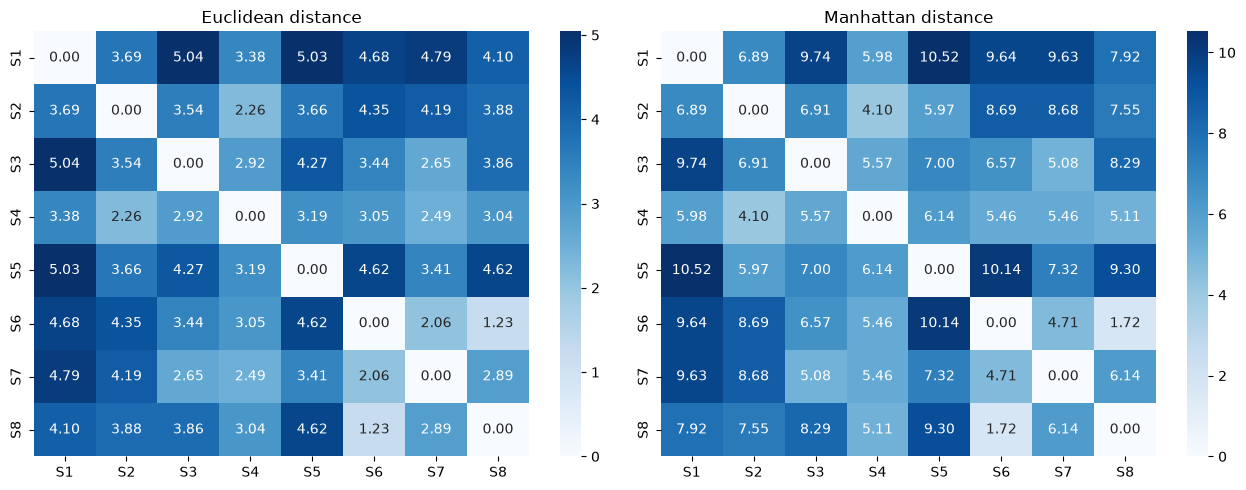

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.heatmap(euclidean_df, annot=True, fmt=".2f", cmap="Blues", ax=axes[0])
axes[0].set_title("Euclidean distance")
sns.heatmap(manhattan_df, annot=True, fmt=".2f", cmap="Blues", ax=axes[1])
axes[1].set_title("Manhattan distance")
plt.tight_layout()
plt.show()

## Observations

S6 and S8 are the closest pair in both matrices, euclidean distance 1.229 and manhattan distance 1.724, the lowest value in both matrices. Looking at their raw data this makes sense, both have extracurricular rating 5, technical rating 5, package expectation 20 LPA, and their CIA, GPA, attendance values are also close to each other.

S1 is far from most other students in both matrices. S1 has attendance of 77 percent while every other student has 96 percent or above, this one feature makes S1 stand out a lot after scaling.

The two methods do not fully agree on which pair is the farthest. Euclidean distance is highest for S1 and S3 (5.044), manhattan distance is highest for S1 and S5 (10.523). S5 has a package expectation of 40 LPA which is much higher than everyone else, so when we just add up absolute differences (manhattan) this one large gap adds up a lot, but in euclidean distance it does not dominate as much since it is only one feature out of six.

Manhattan values are bigger than euclidean values for the same pair of students, since manhattan just adds differences while euclidean squares them and then takes a square root, which brings the number down.

Both matrices are symmetric and the diagonal is 0, distance of a student from themself.